# 0.30 — theme → company basket via SEC filings (naive count baseline)

Last stage of the pipeline: a detected theme (a **bag of entity words** from 0.28/0.29)
becomes a **basket of US companies**, scored by how often the theme terms occur in their
SEC filings (10-K/10-Q).

**Method** (`theme_basket.py`). Downloading filings for all ~9k universe tickers would be
tens of GB, so we first ask **EDGAR full-text search** (free, coverage 2001+) *which*
filings mention each term inside a window `[as_of − lookback, as_of + lookahead]`
(filing date), download only those, and count term occurrences locally. Companies with
no hit score 0 by construction. Terms with more than `max_hits_per_term` hits
(`google`, `microsoft`, `jpmorgan`) are **too generic to shortlist on** — they are still
counted inside the filings the specific terms selected.

**Caveats (baseline, on purpose).**
- Raw occurrence counts — no tf-idf, no section weighting, no de-boilerplating.
- SEC's ticker→CIK map covers *current* registrants → roughly half of the Bloomberg
  list (delisted names, ETFs, SPAC units, warrants) does not resolve and scores 0.
- Foreign private issuers filing 20-F (BABA, BIDU themselves!) are out of scope —
  only 10-K/10-Q root forms are searched.
- Mentioning ≠ being exposed: a filing citing "nvidia" may be a supplier, a customer,
  or a bagholder. That's exactly the naivety this baseline is meant to expose.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt
import theme_basket as tb

pd.set_option("display.width", 200)

# genAI theme from 0.29 (entity BOW from 0.28's anchors+partners; promote = first fire)
THEME = dict(
    vocab=['alibaba', 'altman', 'baidu', 'chatgpt', 'chatgpt-like', 'chatgpt-style',
           'ernie', 'google', 'jpmorgan', 'microsoft', 'netease', 'nvidia', 'openai'],
    promote="2023-01-17")
VOCAB, PROMOTE = THEME["vocab"], THEME["promote"]
MAX_HITS = 1000                     # per-term EFTS hits above this -> generic, no shortlisting

## 1 · Universe: Bloomberg tickers → SEC CIKs

`ticker_list_US.csv` (8,944 Bloomberg `US Equity` names) resolved through SEC's
`company_tickers.json`. Unresolved names are ETFs, SPAC units/warrants and **delisted
tickers** (the SEC map is current-registrants-only) — a known point-in-time limitation
of the baseline.

In [2]:
universe = tb.load_universe()
by_cik, unresolved = tb.resolve_universe(universe, tb.load_cik_map())
print(f"tickers in list      : {len(universe):,}")
print(f"resolved to CIKs     : {len(by_cik):,} issuers")
print(f"unresolved           : {len(unresolved):,}  e.g. {unresolved[:8]}")

tickers in list      : 8,945
resolved to CIKs     : 4,408 issuers
unresolved           : 4,522  e.g. ['AAAP', 'AABA', 'AACC', 'AACQU', 'AACT-U', 'AADI', 'AAI', 'AAIC']


## 2 · Term specificity: EFTS hit totals per vocab term

How many 10-K/10-Q filings mention each term in `[promote − 365d, promote + 120d]`?
This decides which terms can *shortlist* filings and which are generic.

In [3]:
startdt, enddt = tb.make_window(PROMOTE, 365, 120)
totals = {t: tb.fts_total(t, startdt, enddt)[0] for t in VOCAB}
tot = (pd.Series(totals).rename("filings").to_frame()
         .assign(generic=lambda d: d.filings > MAX_HITS)
         .sort_values("filings"))
tot

,filings,generic
chatgpt-like,0,False
chatgpt-style,0,False
openai,11,False
netease,13,False
chatgpt,14,False
ernie,55,False
baidu,66,False
altman,177,False
alibaba,178,False
nvidia,181,False


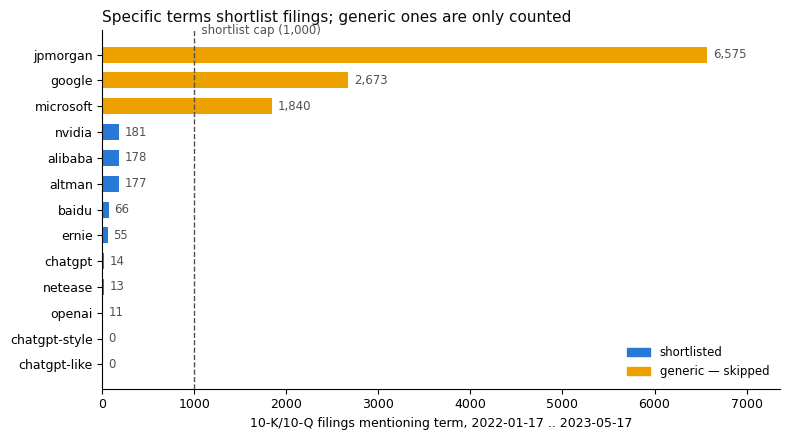

In [4]:
BLUE, YELLOW, INK, MUTED = "#2a78d6", "#eda100", "#0b0b0b", "#52514e"
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [YELLOW if g else BLUE for g in tot.generic]
ax.barh(tot.index, tot.filings, color=colors, height=0.62)
for y, v in enumerate(tot.filings):
    ax.text(v + 60, y, f"{v:,}", va="center", fontsize=8.5, color=MUTED)
ax.axvline(MAX_HITS, color=MUTED, lw=1, ls="--")
ax.text(MAX_HITS, len(tot) - 0.2, f"  shortlist cap ({MAX_HITS:,})", fontsize=8.5, color=MUTED)
ax.set_xlabel(f"10-K/10-Q filings mentioning term, {startdt} .. {enddt}", fontsize=9)
ax.set_title("Specific terms shortlist filings; generic ones are only counted",
             fontsize=11, loc="left", color=INK)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=BLUE, label="shortlisted"),
                   plt.Rectangle((0, 0), 1, 1, color=YELLOW, label="generic — skipped")],
          fontsize=8.5, frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## 3 · Point-in-time basket (`lookahead = 0`)

Only filings filed **on or before promotion day** (2023-01-17). `chatgpt`/`openai`
barely exist in filings yet (ChatGPT launched 2022-11-30; FY2022 10-Ks arrive
Feb–Mar 2023) — the point-in-time basket is carried by the *incumbent* entities
(`nvidia`, `baidu`, `alibaba`, …).

In [5]:
res_pit = tb.build_basket(VOCAB, PROMOTE, lookback_days=365, lookahead_days=0,
                          max_hits_per_term=MAX_HITS)
basket_pit = res_pit["basket"]
show = ["ticker", "company", "n_filings", "total", "n_terms_hit", "per_1k_words",
        "chatgpt", "openai", "nvidia", "baidu", "alibaba", "altman"]
basket_pit[show].head(15)

window: 2022-01-17 .. 2023-01-17  forms: 10-K,10-Q
universe: 4408 issuers resolved to CIKs, 4522 tickers unresolved (ETFs/units/warrants score 0)


  'alibaba': 115 filings, 50 in universe


  'altman': 107 filings, 34 in universe


  'baidu': 42 filings, 25 in universe


  'chatgpt': 0 filings, 0 in universe


...

  scored 125/188 filings


  scored 150/188 filings


  scored 175/188 filings


  scored 188/188 filings


,ticker,company,n_filings,total,n_terms_hit,per_1k_words,chatgpt,openai,nvidia,baidu,alibaba,altman
0,NVDA,NVIDIA CORP,4,613,5,4.213,0,0,600,1,1,0
1,TRIP,"TripAdvisor, Inc.",1,24,5,0.319,0,0,0,2,2,0
2,GOOG,Alphabet Inc.,1,269,4,5.088,0,0,0,1,1,0
3,EA,ELECTRONIC ARTS INC.,1,39,4,0.737,0,0,0,0,0,0
4,MYPS,"PLAYSTUDIOS, Inc.",4,129,4,0.602,0,0,0,0,0,0
5,APPS,"Digital Turbine, Inc.",2,32,4,0.269,0,0,0,3,0,0
6,EXPE,"Expedia Group, Inc.",1,18,4,0.244,0,0,0,0,1,2
7,EBAY,EBAY INC,1,11,4,0.172,0,0,0,1,2,0
8,CRNC,Cerence Inc.,1,4,4,0.058,0,0,0,1,1,0
9,FFAI,FARADAY FUTURE INTELLIGENT ELECTRIC INC.,1,7,4,0.055,0,0,1,3,0,0


## 4 · +120 days lookahead: the basket fills in during 10-K season

Same window start, but filings up to 2023-05-17 now count. This is *not* tradeable at
promote — it shows **how fast the filing signal catches up** with the news signal that
fired on 2023-01-17.

In [6]:
res_120 = tb.build_basket(VOCAB, PROMOTE, lookback_days=365, lookahead_days=120,
                          max_hits_per_term=MAX_HITS)
basket_120 = res_120["basket"]
basket_120[show].head(20)

window: 2022-01-17 .. 2023-05-17  forms: 10-K,10-Q
universe: 4408 issuers resolved to CIKs, 4522 tickers unresolved (ETFs/units/warrants score 0)


  'alibaba': 178 filings, 77 in universe


  'altman': 177 filings, 55 in universe


  'baidu': 66 filings, 38 in universe


  'chatgpt': 14 filings, 10 in universe


...

  scored 225/298 filings


  scored 250/298 filings


  scored 275/298 filings


  scored 298/298 filings


,ticker,company,n_filings,total,n_terms_hit,per_1k_words,chatgpt,openai,nvidia,baidu,alibaba,altman
0,NVDA,NVIDIA CORP,5,918,5,3.875,0,0,896,2,2,0
1,TRIP,"TripAdvisor, Inc.",1,24,5,0.319,0,0,0,2,2,0
2,GOOG,Alphabet Inc.,1,269,4,5.088,0,0,0,1,1,0
3,EA,ELECTRONIC ARTS INC.,1,39,4,0.737,0,0,0,0,0,0
4,MYPS,"PLAYSTUDIOS, Inc.",5,167,4,0.589,0,0,0,0,0,0
5,VUZI,Vuzix Corp,1,19,4,0.351,1,1,0,0,0,0
6,APPS,"Digital Turbine, Inc.",2,32,4,0.269,0,0,0,3,0,0
7,EXPE,"Expedia Group, Inc.",2,36,4,0.258,0,0,0,0,2,4
8,INOD,INNODATA INC,1,9,4,0.210,1,2,0,0,0,0
9,EBAY,EBAY INC,2,20,4,0.155,0,0,0,2,4,0


In [7]:
# who talks about ChatGPT/OpenAI once the 10-K/10-Q season lands?
direct = basket_120[(basket_120.chatgpt > 0) | (basket_120.openai > 0)]
print(f"companies mentioning chatgpt/openai: point-in-time = "
      f"{int(((basket_pit.chatgpt > 0) | (basket_pit.openai > 0)).sum())}, "
      f"+120d = {len(direct)}")
direct[show].head(15)

companies mentioning chatgpt/openai: point-in-time = 1, +120d = 13


,ticker,company,n_filings,total,n_terms_hit,per_1k_words,chatgpt,openai,nvidia,baidu,alibaba,altman
5,VUZI,Vuzix Corp,1,19,4,0.351,1,1,0,0,0,0
8,INOD,INNODATA INC,1,9,4,0.210,1,2,0,0,0,0
10,VERI,"Veritone, Inc.",6,24,4,0.111,2,0,6,0,0,0
11,STGW,Stagwell Inc,1,5,4,0.062,1,0,0,0,0,0
13,RXRX,"RECURSION PHARMACEUTICALS, INC.",2,9,4,0.044,1,0,4,0,0,0
15,OKLO,Oklo Inc.,6,107,3,0.563,0,16,0,0,0,90
18,LPSN,LIVEPERSON INC,1,30,3,0.365,0,1,0,0,0,0
46,SKIL,Skillsoft Corp.,1,3,3,0.044,1,1,0,0,0,0
48,MSFT,MICROSOFT CORP,1,61,2,1.774,0,2,0,0,0,0
58,SSTK,"Shutterstock, Inc.",2,8,2,0.100,0,6,0,0,0,0


## 5 · Takeaways

- **The mechanism works end-to-end**: vocab → EFTS shortlist → targeted downloads →
  count matrix → ranked basket, fully cached (`data/raw/edgar/`), reruns are offline.
- **Point-in-time honesty**: at promote (Jan 17 2023) the *filing* channel barely knows
  ChatGPT — the news channel (0.28/0.29) fires first, filings confirm within one
  reporting season (`lookahead=120` picks up direct mentioners like VERI, INOD, VUZI).
- **Naive counts have obvious failure modes**, visible above: surname collisions
  (`altman` hits unrelated filers), mention-≠-exposure, incumbents (MSFT, NVDA, GOOGL)
  are *in the vocab* rather than among the mentioners, and 20-F filers are invisible.
  Compare the Roundhill CHAT ETF (launched 2023-05-18): its top holdings (NVDA, MSFT,
  GOOGL, BIDU, …) are the theme's *anchors*; our count basket instead surfaces the
  *adopters/satellites*. Both are legitimate basket philosophies — worth separating
  explicitly in the next iteration.
- **Next steps**: per-1k normalization is in place; add tf-idf-style down-weighting of
  boilerplate, section-aware counting (Item 1/1A/7), a market-cap/liquidity screen, and
  a historical ticker→CIK map for delisted names.

Reproduce from the CLI (idempotent, manifest-certified):
```bash
python scripts/build_theme_basket.py --name genai --as-of 2023-01-17 \
    --lookback 365 --lookahead 120 \
    --vocab alibaba altman baidu chatgpt chatgpt-like chatgpt-style ernie \
            google jpmorgan microsoft netease nvidia openai
```
Outputs: `data/processed/theme_basket_genai{,_filings}.parquet` + manifest.